# Stage 08 — Environmental relief-access POC

## Purpose

Stage 06 identified **observed behavioural persistence and change** from Locomizer.

Stage 07 added **CAFEIN mobility-accessibility context**.

Stage 08 now asks:

> **Are high-priority persistent-activity H3 cells close to potentially restorative environmental opportunities?**

For this proof of concept, the environmental opportunity is **access to high-green-view streets**.

This is not the same as a validated cleaner-air space, cooling centre, or health-protective refuge. It is a demonstrator showing that the workflow can replace generic destinations with an environmentally meaningful opportunity set.

The logic is:

**Observed persistent activity → mobility context → access to greener environmental opportunities**

Later, the same routing workflow can use real:
- cleaner-air spaces,
- cooling centres,
- libraries/public buildings,
- health facilities,
- parks,
- low-exposure refuges,
- or other event-specific destinations.


## 1. Imports and paths

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import cafein.sampledata.helsinki as helsinki
from cafein import StreetNetwork, TravelTimeMatrix

PROJECT_ROOT = Path("/scratch/project_2010417")

STAGE07_DIR_CANDIDATES = [
    Path("../outputs/v3/07_cafein_accessibility_context"),
    PROJECT_ROOT / "paper3" / "outputs" / "v3" / "07_cafein_accessibility_context",
]

STAGE07_GPKG_NAME = "stage07_cafein_accessibility_context.gpkg"
STAGE07_PRIORITY_NAME = "stage07_persistent_activity_accessibility_priority.csv"

STREET_NETWORK_CANDIDATES = [
    Path("helsinki-region-streets.cafein"),
    PROJECT_ROOT / "paper3" / "helsinki-region-streets.cafein",
    PROJECT_ROOT / "paper3" / "cafein" / "helsinki-region-streets.cafein",
    PROJECT_ROOT / "paper3" / "networks" / "helsinki-region-streets.cafein",
]

OUTPUT_DIR = Path(
    "../outputs/v3/08_environmental_relief_access"
)
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# POC settings
GREEN_VIEW_QUANTILE = 0.90
GREEN_DEST_SPACING_M = 750

print("Output:", OUTPUT_DIR.resolve())


Output: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/outputs/v3/08_environmental_relief_access


## 2. Locate Stage 07 outputs

In [2]:
def first_existing(directory_candidates, filename):
    checked = []
    for directory in directory_candidates:
        path = directory / filename
        checked.append(path)
        if path.exists():
            print("Using:", path.resolve())
            return path

    raise FileNotFoundError(
        "Could not find required file. Checked:\n"
        + "\n".join(str(p) for p in checked)
    )

stage07_gpkg = first_existing(
    STAGE07_DIR_CANDIDATES,
    STAGE07_GPKG_NAME,
)

stage07_priority_csv = first_existing(
    STAGE07_DIR_CANDIDATES,
    STAGE07_PRIORITY_NAME,
)


Using: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/outputs/v3/07_cafein_accessibility_context/stage07_cafein_accessibility_context.gpkg
Using: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/outputs/v3/07_cafein_accessibility_context/stage07_persistent_activity_accessibility_priority.csv


## 3. Load high-priority behavioural-accessibility H3 cells

In [3]:
h3_context = gpd.read_file(
    stage07_gpkg,
    layer="h3_accessibility_context",
)

priority = pd.read_csv(
    stage07_priority_csv
)

print("Mapped H3 cells:", len(h3_context))
print("Priority rows:", len(priority))

display(priority.head(15))


Mapped H3 cells: 30
Priority rows: 30


,id,persistence_rate,activity_share_A,relative_activity_shift,poc_priority_score,geometry,walk_nearest_min,walk_median_min,walk_reachable_n,bike_nearest_min,bike_median_min,bike_reachable_n,lower_cost_access_option,mobility_context,persistent_activity,integrated_context,access_burden_score,integrated_priority_score
0,8908996b073ffff,0.646512,0.000851,0.000279,0.735379,POINT (24.66641419683264 60.147768544326645),14,70.0,12,5,70.5,62,True,lower accessibility constraint,True,persistent activity + lower accessibility cons...,0.258333,0.189973
1,8908996988bffff,0.638743,0.000851,-0.000677,0.705715,POINT (24.807088620971538 60.17738959026876),6,89.0,24,2,50.0,71,True,lower accessibility constraint,True,persistent activity + lower accessibility cons...,0.033333,0.023524
2,891126d1977ffff,0.649789,0.000681,-0.000246,0.701655,POINT (25.095326851487876 60.213477949608595),16,43.0,12,5,78.0,71,True,lower accessibility constraint,True,persistent activity + lower accessibility cons...,0.291667,0.204650
3,8908996d493ffff,0.622549,0.001276,-0.000146,0.676770,POINT (24.804747113829183 60.26982602314292),23,92.0,20,7,62.0,75,True,lower accessibility constraint,True,persistent activity + lower accessibility cons...,0.416667,0.281987
4,891126c242fffff,0.639485,0.000681,-0.000246,0.666639,POINT (25.115574310628155 60.237893577489686),46,77.0,12,12,75.5,68,False,higher accessibility constraint,True,persistent activity + higher accessibility con...,0.841667,0.561088
5,89089968553ffff,0.733696,0.000425,0.000009,0.666014,POINT (24.70315285960791 60.1989994115981),36,89.0,19,10,60.5,70,True,lower accessibility constraint,True,persistent activity + lower accessibility cons...,0.625000,0.416259
6,8908996a48bffff,0.729167,0.000425,-0.000078,0.664659,POINT (24.586749260358104 60.199126036887904),105,105.0,1,27,72.0,55,False,higher accessibility constraint,True,persistent activity + higher accessibility con...,1.000000,0.664659
7,891126d2a17ffff,0.638554,0.000681,-0.000246,0.661804,POINT (24.969198043534462 60.24424182899503),41,88.0,10,11,52.0,75,False,higher accessibility constraint,True,persistent activity + higher accessibility con...,0.750000,0.496353
8,891126d26a7ffff,0.721591,0.000425,-0.000165,0.660324,POINT (24.867464963456243 60.20952528426695),16,102.0,23,5,46.0,69,True,lower accessibility constraint,True,persistent activity + lower accessibility cons...,0.291667,0.192594
9,891126d0d13ffff,0.620833,0.001106,0.000372,0.655886,POINT (25.018724523126178 60.26277903419475),25,89.0,9,7,59.0,75,True,lower accessibility constraint,True,persistent activity + lower accessibility cons...,0.450000,0.295149


## 4. Define the environmental opportunity set

CAFEIN's Helsinki sample includes street segments with **Combined Green View Index (`Comb_GVI`)**.

We define the top 10% of mapped green-view street segments as a simple set of **high-green-view environmental opportunities**.

This is a POC choice, not a health threshold.


In [4]:
green_roads = gpd.read_file(
    helsinki.green_view,
    layer="roads",
)

green_roads = green_roads.loc[
    green_roads["Comb_GVI"].notna()
].copy()

green_threshold = green_roads["Comb_GVI"].quantile(
    GREEN_VIEW_QUANTILE
)

high_green = green_roads.loc[
    green_roads["Comb_GVI"] >= green_threshold
].copy()

print(
    f"High-green-view threshold "
    f"(top {int((1-GREEN_VIEW_QUANTILE)*100)}%): "
    f"{green_threshold:.1f}"
)
print("High-green road segments:", len(high_green))

display(
    high_green[
        ["Comb_GVI", "geometry"]
    ].head()
)


High-green-view threshold (top 9%): 53.4
High-green road segments: 5617


,Comb_GVI,geometry
9,63.0,"MULTILINESTRING ((383363.649 6678773.283, 3833..."
25,59.5,"MULTILINESTRING ((386092.38 6675370.049, 38609..."
65,79.4,"MULTILINESTRING ((401446.837 6681029.031, 4014..."
81,67.1,"MULTILINESTRING ((381313.282 6677109.69, 38130..."
87,63.1,"MULTILINESTRING ((382893.184 6679457.351, 3828..."


## 5. Convert high-green street segments into a manageable destination set

Routing to every green street segment would be unnecessary for this POC.

We:
1. convert high-green segments to representative points;
2. project them to EPSG:3067;
3. thin them spatially to roughly one opportunity per 750 m grid cell.

This produces a compact set of distributed environmental opportunity destinations.


In [5]:
green_points = high_green.to_crs(
    "EPSG:3067"
).copy()

green_points["geometry"] = (
    green_points.geometry.representative_point()
)

green_points["grid_x"] = (
    green_points.geometry.x
    // GREEN_DEST_SPACING_M
).astype(int)

green_points["grid_y"] = (
    green_points.geometry.y
    // GREEN_DEST_SPACING_M
).astype(int)

green_destinations = (
    green_points
    .sort_values(
        "Comb_GVI",
        ascending=False,
    )
    .drop_duplicates(
        subset=["grid_x", "grid_y"]
    )
    .copy()
)

green_destinations["id"] = [
    f"green_{i}"
    for i in range(len(green_destinations))
]

green_destinations = green_destinations[
    [
        "id",
        "Comb_GVI",
        "geometry",
    ]
].to_crs("EPSG:4326")

print(
    "Thinned high-green destinations:",
    len(green_destinations),
)

display(green_destinations.head())


Thinned high-green destinations: 379


,id,Comb_GVI,geometry
28885,green_0,97.9,POINT (24.96141 60.23594)
11061,green_1,96.4,POINT (25.01384 60.19777)
33312,green_2,96.4,POINT (24.93426 60.23572)
50534,green_3,96.0,POINT (25.01198 60.27242)
10800,green_4,95.5,POINT (25.04408 60.17464)


## 6. Map the selected H3 cells and green opportunities

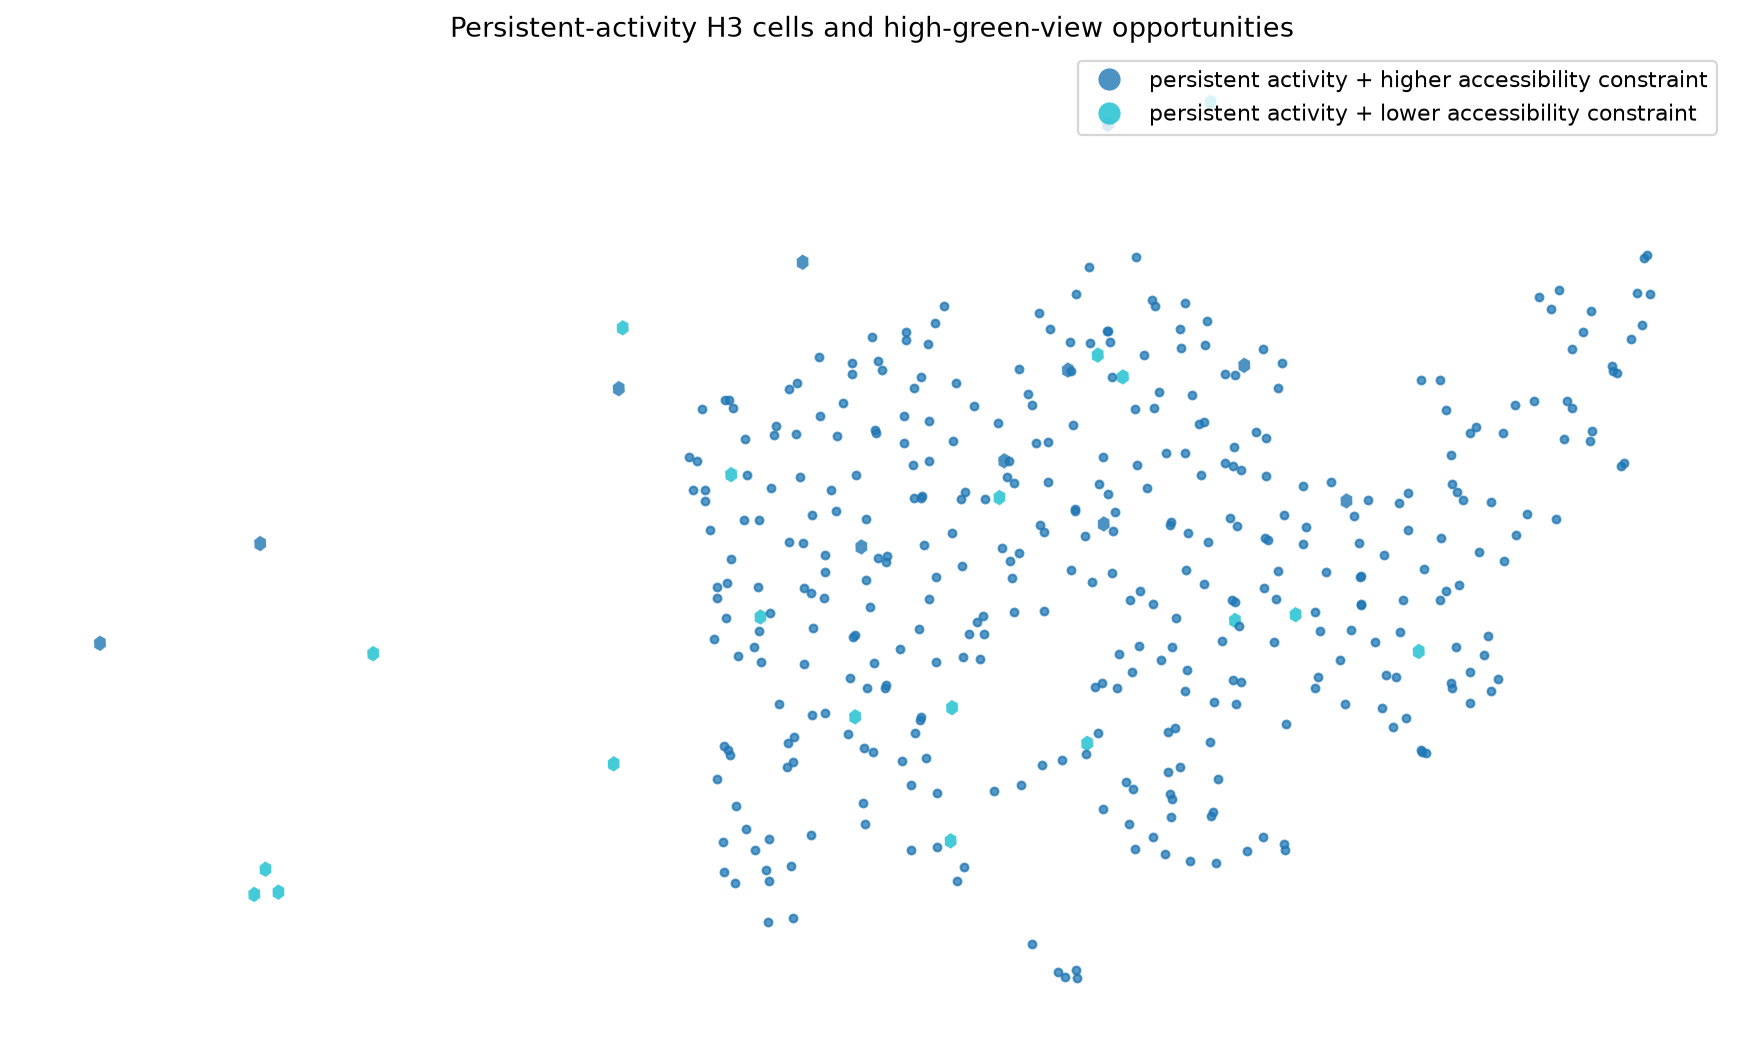

In [6]:
h3_map = h3_context.to_crs(
    "EPSG:3067"
)

green_map = green_destinations.to_crs(
    "EPSG:3067"
)

fig, ax = plt.subplots(
    figsize=(11, 9),
    dpi=160,
)

h3_map.plot(
    ax=ax,
    column="integrated_context",
    categorical=True,
    legend=True,
    linewidth=0.25,
    edgecolor="white",
    alpha=0.80,
)

green_map.plot(
    ax=ax,
    markersize=12,
    alpha=0.75,
)

ax.set_title(
    "Persistent-activity H3 cells and high-green-view opportunities"
)
ax.set_axis_off()

plt.tight_layout()
plt.show()


## 7. Build origin points from Stage 07 H3 cells

In [7]:
origins = h3_context.to_crs(
    "EPSG:4326"
).copy()

origins["geometry"] = (
    origins.geometry.representative_point()
)

origins = origins[
    [
        "id",
        "persistence_rate",
        "activity_share_A",
        "relative_activity_shift",
        "poc_priority_score",
        "walk_nearest_min",
        "bike_nearest_min",
        "integrated_context",
        "geometry",
    ]
].copy()

display(origins.head())


,id,persistence_rate,activity_share_A,relative_activity_shift,poc_priority_score,walk_nearest_min,bike_nearest_min,integrated_context,geometry
0,8908996b073ffff,0.646512,0.000851,0.000279,0.735379,14,5,persistent activity + lower accessibility cons...,POINT (24.66641 60.14777)
1,8908996988bffff,0.638743,0.000851,-0.000677,0.705715,6,2,persistent activity + lower accessibility cons...,POINT (24.80709 60.17739)
2,891126d1977ffff,0.649789,0.000681,-0.000246,0.701655,16,5,persistent activity + lower accessibility cons...,POINT (25.09533 60.21348)
3,8908996d493ffff,0.622549,0.001276,-0.000146,0.676770,23,7,persistent activity + lower accessibility cons...,POINT (24.80475 60.26983)
4,891126c242fffff,0.639485,0.000681,-0.000246,0.666639,46,12,persistent activity + higher accessibility con...,POINT (25.11557 60.23789)


## 8. Load or build the CAFEIN street network

In [8]:
street_path = None

for candidate in STREET_NETWORK_CANDIDATES:
    if candidate.exists():
        street_path = candidate
        break

if street_path is not None:
    print("Loading:", street_path.resolve())
    streets = StreetNetwork.load(
        street_path,
        mmap=True,
    )
else:
    print(
        "No saved street network found. "
        "Building one from the CAFEIN Helsinki sample."
    )

    streets = StreetNetwork.from_osm(
        helsinki.osm_pbf,
        modes=(
            "walk",
            "bicycle",
            "e_scooter",
            "wheelchair",
            "car",
        ),
        dem=helsinki.dem,
        dem_interval=25,
        country="FI",
    )

print(streets)


Loading: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/notebooks/helsinki-region-streets.cafein
StreetNetwork(1474309 vertices, 1644890 edges)


## 9. Route from behavioural-priority H3 cells to high-green-view opportunities

We calculate:
- walking travel time;
- cycling travel time.

This is the same CAFEIN matrix logic used in Stage 07, but the destinations are now environmentally meaningful.


In [9]:
walk_green = TravelTimeMatrix(
    streets,
    origins,
    green_destinations,
    transport_mode="walk",
)

bike_green = TravelTimeMatrix(
    streets,
    origins,
    green_destinations,
    transport_mode="bicycle",
)

print("Walking matrix rows:", len(walk_green))
print("Cycling matrix rows:", len(bike_green))

display(walk_green.head())


Walking matrix rows: 2485
Cycling matrix rows: 10350


,from_id,to_id,travel_time
0,8908996988bffff,green_29,105
1,8908996988bffff,green_42,110
2,8908996988bffff,green_65,119
3,8908996988bffff,green_80,54
4,8908996988bffff,green_86,120


## 10. Summarize green-opportunity accessibility

In [10]:
def summarize_access(matrix, prefix):
    return (
        matrix
        .groupby(
            "from_id",
            as_index=False,
        )
        .agg(
            nearest_min=(
                "travel_time",
                "min",
            ),
            median_min=(
                "travel_time",
                "median",
            ),
            reachable_n=(
                "to_id",
                "nunique",
            ),
        )
        .rename(
            columns={
                "from_id": "id",
                "nearest_min": f"{prefix}_nearest_min",
                "median_min": f"{prefix}_median_min",
                "reachable_n": f"{prefix}_reachable_n",
            }
        )
    )

walk_green_summary = summarize_access(
    walk_green,
    "green_walk",
)

bike_green_summary = summarize_access(
    bike_green,
    "green_bike",
)

relief = (
    origins
    .merge(
        walk_green_summary,
        on="id",
        how="left",
    )
    .merge(
        bike_green_summary,
        on="id",
        how="left",
    )
)

display(
    relief.sort_values(
        "green_walk_nearest_min",
        ascending=False,
    )
)


,id,persistence_rate,activity_share_A,relative_activity_shift,poc_priority_score,walk_nearest_min,bike_nearest_min,integrated_context,geometry,green_walk_nearest_min,green_walk_median_min,green_walk_reachable_n,green_bike_nearest_min,green_bike_median_min,green_bike_reachable_n
13,891126d4693ffff,0.618785,0.001106,-0.000932,0.644294,10,4,persistent activity + lower accessibility cons...,POINT (25.05267 60.32151),74.0,106.0,15.0,19,63.5,368
12,891126d7577ffff,0.644351,0.000595,0.000187,0.651049,59,17,persistent activity + higher accessibility con...,POINT (25.00908 60.31621),62.0,102.0,21.0,16,61.0,368
3,8908996d493ffff,0.622549,0.001276,-0.000146,0.676770,23,7,persistent activity + lower accessibility cons...,POINT (24.80475 60.26983),56.0,94.0,31.0,14,65.5,362
18,8908996d147ffff,0.688119,0.000425,-0.000251,0.632957,37,11,persistent activity + higher accessibility con...,POINT (24.88059 60.28495),51.0,94.0,46.0,14,61.0,368
1,8908996988bffff,0.638743,0.000851,-0.000677,0.705715,6,2,persistent activity + lower accessibility cons...,POINT (24.80709 60.17739),47.0,100.0,40.0,12,64.0,351
24,890899689a3ffff,0.626087,0.000681,0.000450,0.609113,51,14,persistent activity + higher accessibility con...,POINT (24.80393 60.25692),41.0,95.0,43.0,11,62.0,362
22,891126d0687ffff,0.623116,0.000766,0.000364,0.618289,27,8,persistent activity + lower accessibility cons...,POINT (24.95025 60.19159),17.0,90.0,146.0,5,36.5,368
20,891126d2b3bffff,0.680723,0.000425,-0.000251,0.623745,38,11,persistent activity + higher accessibility con...,POINT (24.99518 60.26388),14.0,78.0,122.0,3,41.0,368
23,891126c3537ffff,0.616162,0.000936,-0.000588,0.609745,8,6,persistent activity + lower accessibility cons...,POINT (25.1482 60.20643),13.0,71.0,91.0,5,50.5,368
28,891126d3347ffff,0.623188,0.000681,-0.000159,0.597274,13,7,persistent activity + lower accessibility cons...,POINT (24.95142 60.16336),11.0,91.5,78.0,4,47.0,368


## 11. Create an environmental-relief access burden score

For each selected H3 cell, rank:
- walking time to nearest high-green opportunity;
- cycling time to nearest high-green opportunity.

The mean of those percentile ranks becomes an exploratory **green-relief access burden**.

Higher values = relatively weaker access among the selected POC origins.


In [11]:
relief["green_walk_burden_rank"] = (
    relief["green_walk_nearest_min"]
    .rank(
        pct=True,
        method="average",
    )
)

relief["green_bike_burden_rank"] = (
    relief["green_bike_nearest_min"]
    .rank(
        pct=True,
        method="average",
    )
)

relief["green_relief_burden"] = (
    relief["green_walk_burden_rank"]
    + relief["green_bike_burden_rank"]
) / 2

relief["behaviour_green_priority"] = (
    relief["poc_priority_score"]
    * relief["green_relief_burden"]
)

display(
    relief.sort_values(
        "behaviour_green_priority",
        ascending=False,
    )[
        [
            "id",
            "persistence_rate",
            "activity_share_A",
            "green_walk_nearest_min",
            "green_bike_nearest_min",
            "green_relief_burden",
            "behaviour_green_priority",
        ]
    ].head(20)
)


,id,persistence_rate,activity_share_A,green_walk_nearest_min,green_bike_nearest_min,green_relief_burden,behaviour_green_priority
13,891126d4693ffff,0.618785,0.001106,74.0,19,0.900000,0.579864
12,891126d7577ffff,0.644351,0.000595,62.0,16,0.862500,0.561530
3,8908996d493ffff,0.622549,0.001276,56.0,14,0.816667,0.552695
1,8908996988bffff,0.638743,0.000851,47.0,12,0.750000,0.529287
18,8908996d147ffff,0.688119,0.000425,51.0,14,0.795833,0.503728
24,890899689a3ffff,0.626087,0.000681,41.0,11,0.712500,0.433993
22,891126d0687ffff,0.623116,0.000766,17.0,5,0.666667,0.412193
23,891126c3537ffff,0.616162,0.000936,13.0,5,0.625000,0.381091
20,891126d2b3bffff,0.680723,0.000425,14.0,3,0.587500,0.366450
2,891126d1977ffff,0.649789,0.000681,10.0,3,0.514583,0.361060


## 12. Map environmental-relief access burden

This map asks:

> among the selected persistent/high-importance activity cells, which ones are relatively farther from high-green-view opportunities?


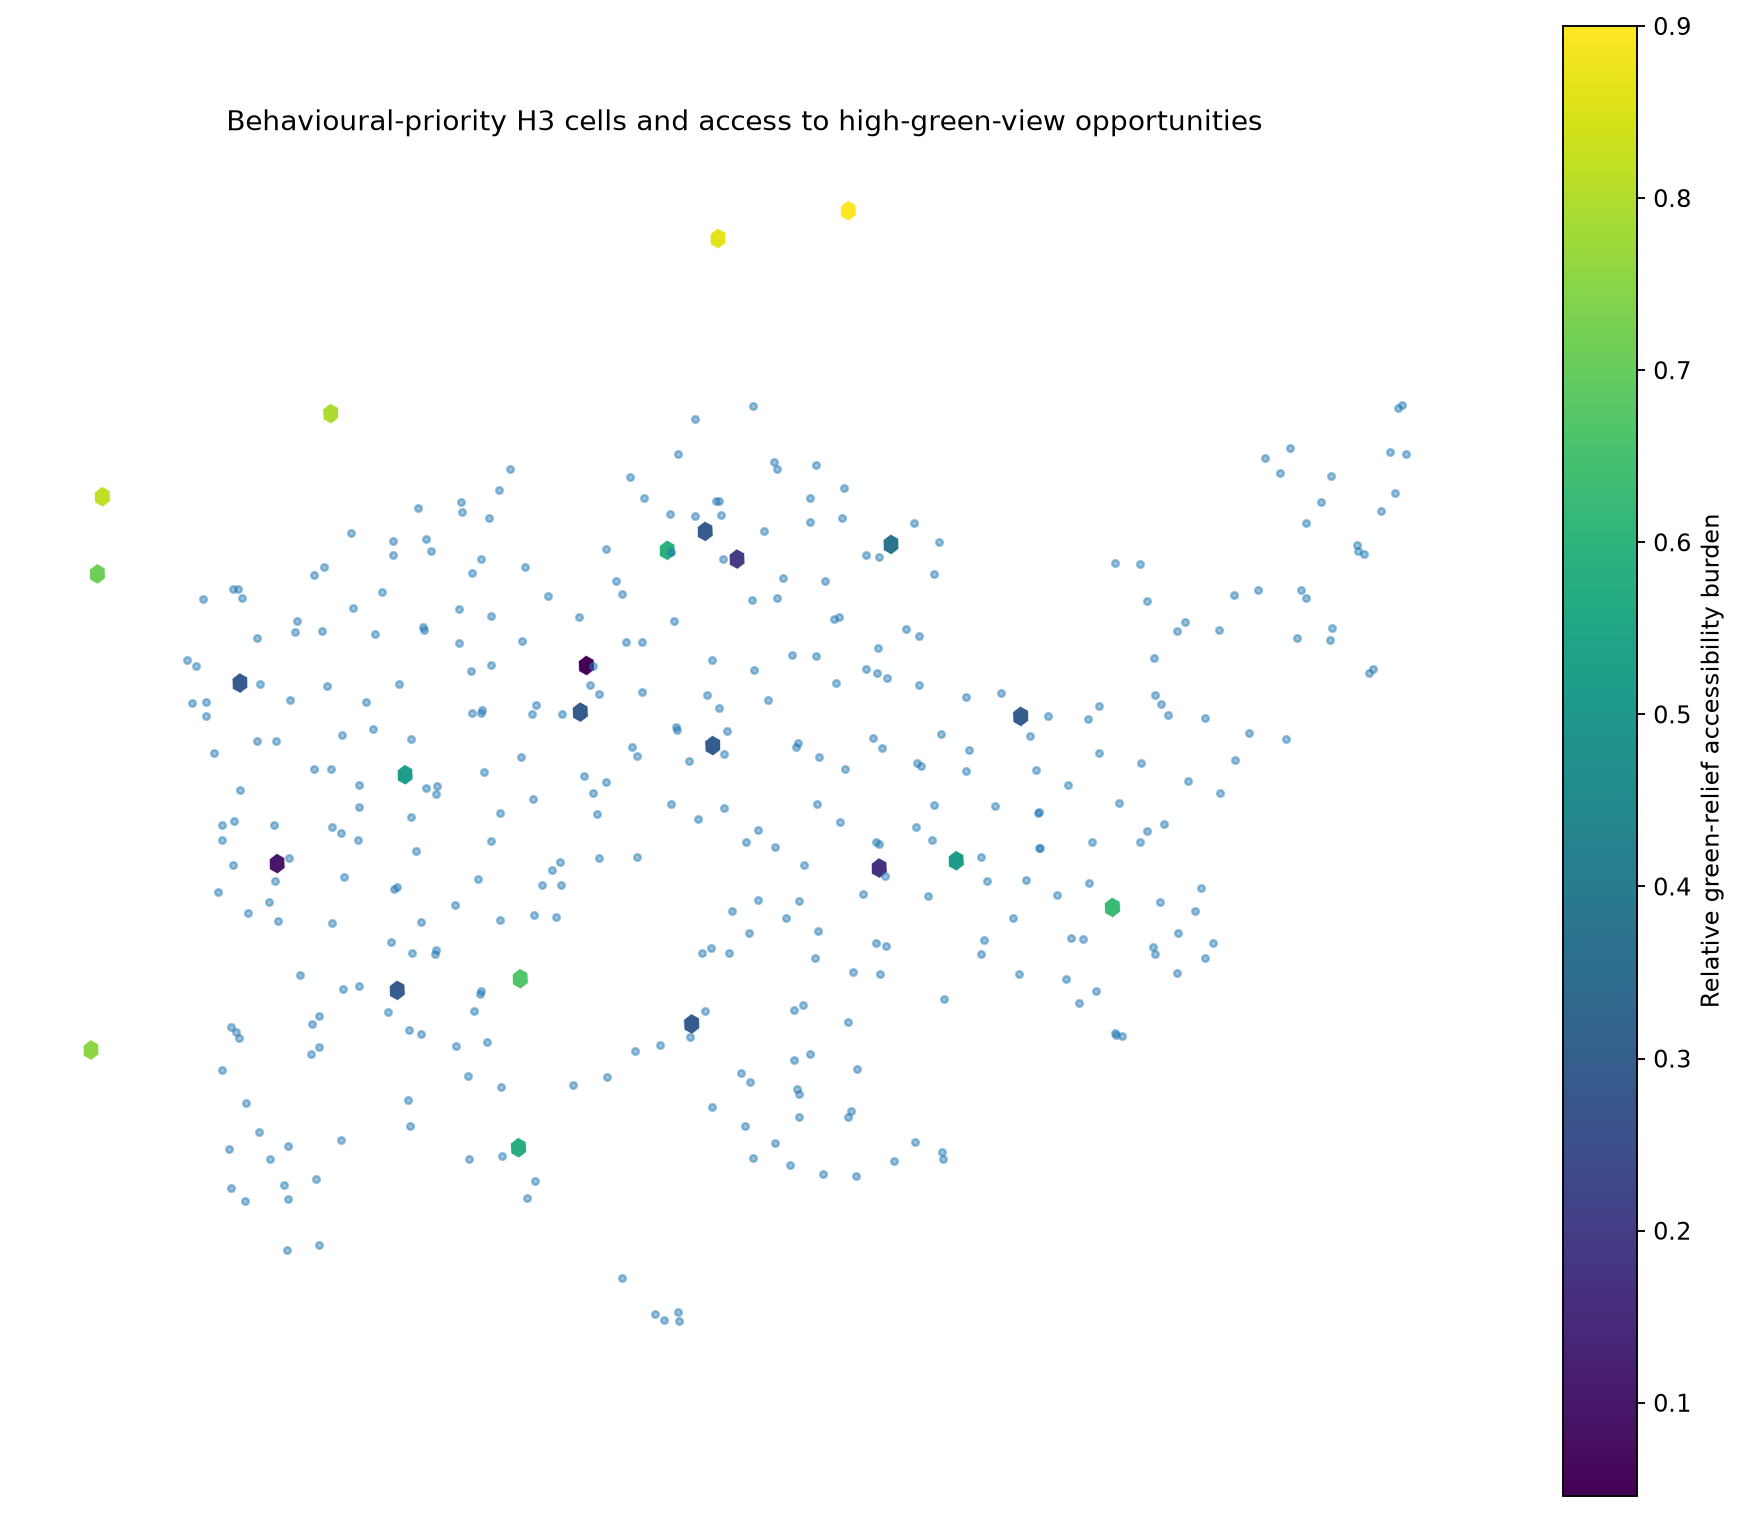

In [12]:
mapped_relief = h3_context[
    [
        "id",
        "geometry",
    ]
].merge(
    relief.drop(
        columns="geometry"
    ),
    on="id",
    how="left",
)

mapped_relief = gpd.GeoDataFrame(
    mapped_relief,
    geometry="geometry",
    crs=h3_context.crs,
).to_crs("EPSG:3067")

fig, ax = plt.subplots(
    figsize=(11, 9),
    dpi=170,
)

mapped_relief.plot(
    ax=ax,
    column="green_relief_burden",
    legend=True,
    linewidth=0.25,
    edgecolor="white",
    legend_kwds={
        "label":
        "Relative green-relief accessibility burden"
    },
)

green_map.plot(
    ax=ax,
    markersize=8,
    alpha=0.45,
)

ax.set_title(
    "Behavioural-priority H3 cells and access to high-green-view opportunities"
)
ax.set_axis_off()

plt.tight_layout()
plt.show()


## 13. Identify the strongest POC cases

The most interesting demonstrator cells are those that combine:

- relatively high observed activity importance;
- relatively high persistence;
- relatively weak access to high-green-view opportunities.

These are not automatically vulnerable populations or transport-poor areas. They are simply the strongest **combined POC signals**.


In [13]:
top_cases = (
    relief
    .sort_values(
        "behaviour_green_priority",
        ascending=False,
    )
    .head(10)
    .copy()
)

display(
    top_cases[
        [
            "id",
            "persistence_rate",
            "activity_share_A",
            "relative_activity_shift",
            "green_walk_nearest_min",
            "green_bike_nearest_min",
            "green_relief_burden",
            "behaviour_green_priority",
            "integrated_context",
        ]
    ]
)


,id,persistence_rate,activity_share_A,relative_activity_shift,green_walk_nearest_min,green_bike_nearest_min,green_relief_burden,behaviour_green_priority,integrated_context
13,891126d4693ffff,0.618785,0.001106,-0.000932,74.0,19,0.900000,0.579864,persistent activity + lower accessibility cons...
12,891126d7577ffff,0.644351,0.000595,0.000187,62.0,16,0.862500,0.561530,persistent activity + higher accessibility con...
3,8908996d493ffff,0.622549,0.001276,-0.000146,56.0,14,0.816667,0.552695,persistent activity + lower accessibility cons...
1,8908996988bffff,0.638743,0.000851,-0.000677,47.0,12,0.750000,0.529287,persistent activity + lower accessibility cons...
18,8908996d147ffff,0.688119,0.000425,-0.000251,51.0,14,0.795833,0.503728,persistent activity + higher accessibility con...
24,890899689a3ffff,0.626087,0.000681,0.000450,41.0,11,0.712500,0.433993,persistent activity + higher accessibility con...
22,891126d0687ffff,0.623116,0.000766,0.000364,17.0,5,0.666667,0.412193,persistent activity + lower accessibility cons...
23,891126c3537ffff,0.616162,0.000936,-0.000588,13.0,5,0.625000,0.381091,persistent activity + lower accessibility cons...
20,891126d2b3bffff,0.680723,0.000425,-0.000251,14.0,3,0.587500,0.366450,persistent activity + higher accessibility con...
2,891126d1977ffff,0.649789,0.000681,-0.000246,10.0,3,0.514583,0.361060,persistent activity + lower accessibility cons...


## 14. What Stage 08 demonstrates

This stage completes an important POC chain:

**Locomizer observed behaviour**
→ persistent/high-importance H3 cells

**CAFEIN mobility context**
→ walking/cycling accessibility

**Environmental opportunity layer**
→ access to high-green-view locations

The result is an integrated screening framework for identifying places where:

> observed activity persists while access to a potentially restorative environmental opportunity is relatively weaker.

This is exactly the structure that can later be reused for real event-relevant destinations such as cleaner-air spaces or cooling centres.


## 15. Important interpretation caveat

The CAFEIN Green View layer describes visible greenery along mapped roads.

It does **not** prove:
- cleaner air,
- thermal comfort,
- availability of indoor refuge,
- public access,
- or health protection.

Therefore, this stage should be described as **environmental opportunity accessibility**, not verified relief accessibility.

For a substantive smoke or heat study, replace this opportunity layer with event-relevant facilities or validated environmental refuge locations.


## 16. Optional next step — route environmental exposure for only the strongest cases

After identifying 5–10 high-priority H3 cells, the next POC step can use CAFEIN `Exposure` and `DetailedItineraries` to compare:

- fastest route;
- environmental conditions along that route;
- possibly an alternative lower-exposure route.

This should be done only for the strongest demonstrator cells rather than for every H3 cell.

The CAFEIN sample PM₂.₅ raster is a **single model-hour snapshot**, so any PM₂.₅ route analysis at this point should be labelled as a technical demonstration rather than historical exposure corresponding to the Locomizer dates.


## 17. Save outputs

In [14]:
relief_csv = (
    OUTPUT_DIR
    / "stage08_environmental_relief_access.csv"
)

relief_gpkg = (
    OUTPUT_DIR
    / "stage08_environmental_relief_access.gpkg"
)

top_cases_csv = (
    OUTPUT_DIR
    / "stage08_top_poc_cases.csv"
)

green_destinations_gpkg = (
    OUTPUT_DIR
    / "stage08_high_green_opportunities.gpkg"
)

walk_matrix_csv = (
    OUTPUT_DIR
    / "stage08_walk_to_green_matrix.csv"
)

bike_matrix_csv = (
    OUTPUT_DIR
    / "stage08_bike_to_green_matrix.csv"
)

relief.drop(
    columns="geometry"
).to_csv(
    relief_csv,
    index=False,
)

mapped_relief.to_file(
    relief_gpkg,
    layer="h3_environmental_relief_access",
    driver="GPKG",
)

top_cases.to_csv(
    top_cases_csv,
    index=False,
)

green_destinations.to_file(
    green_destinations_gpkg,
    layer="high_green_opportunities",
    driver="GPKG",
)

walk_green.to_csv(
    walk_matrix_csv,
    index=False,
)

bike_green.to_csv(
    bike_matrix_csv,
    index=False,
)

print("Saved:")
for p in [
    relief_csv,
    relief_gpkg,
    top_cases_csv,
    green_destinations_gpkg,
    walk_matrix_csv,
    bike_matrix_csv,
]:
    print(" -", p)


Saved:
 - ../outputs/v3/08_environmental_relief_access/stage08_environmental_relief_access.csv
 - ../outputs/v3/08_environmental_relief_access/stage08_environmental_relief_access.gpkg
 - ../outputs/v3/08_environmental_relief_access/stage08_top_poc_cases.csv
 - ../outputs/v3/08_environmental_relief_access/stage08_high_green_opportunities.gpkg
 - ../outputs/v3/08_environmental_relief_access/stage08_walk_to_green_matrix.csv
 - ../outputs/v3/08_environmental_relief_access/stage08_bike_to_green_matrix.csv
